In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import shap 
import torch
import matplotlib.pyplot as plt
from torchinfo import summary as torchsummary
from torchvision import models, transforms
from model import init_model
from matplotlib import pyplot
from pathlib import Path
sns.set(rc={'figure.figsize':(11.7,8.27)})
pd.options.display.max_rows = 999
pd.options.display.max_columns = 999




In [2]:
ROOT_DIR = Path("/data/home/felipemarcelino/google_drive/comp_science/projects/glaucoma")

In [3]:
data = pd.read_csv("../data.csv")
summary = pd.read_csv("../model_summary.csv")
summary.drop_duplicates(inplace=True)

In [42]:
inv_normalize = transforms.Normalize(
   mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
   std=[1/0.229, 1/0.224, 1/0.225]
)
def imshow(image):
    npimg = image.numpy()
    npimg = np.transpose(npimg, (1,2,0))
    npimg = ((npimg * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406])
    return npimg

In [5]:
numerical_columns = data.select_dtypes(include=np.number).columns.tolist()
numerical_columns.remove("label")
ft_size = len(numerical_columns)

In [57]:
features_name = data.iloc[:,5:].columns.values
features_name

array(['gender', 'G', 'T', 'TS', 'NS', 'N', 'NI', 'TI', 'age', 'T/TS',
       'T/NS', 'T/N', 'T/NI', 'T/TI', 'TS/NS', 'TS/N', 'TS/NI', 'TS/TI',
       'NS/N', 'NS/NI', 'NS/TI', 'N/NI', 'N/TI', 'NI/TI'], dtype=object)

In [6]:
summary.columns

Index(['model_id', 'k_fold', 'frac_val', 'val_best_acc', 'val_best_auc',
       'val_best_sp', 'val_best_sn', 'val_avg_acc', 'val_avg_auc',
       'val_avg_sp', 'val_avg_sn', 'train_best_acc', 'train_best_auc',
       'train_best_sp', 'train_best_sn', 'train_avg_acc', 'train_avg_auc',
       'train_avg_sp', 'train_avg_sn', 'host_name', 'is_inception', 'optim',
       'lr', 'epochs', 'double_img', 'output_tab', 'backbone',
       'feature_extract', 'early_start', 'timestamp', 'total_hours',
       'average_cross_hours', 'torchvision_version', 'torch_version'],
      dtype='object')

In [7]:
summary.shape

(624, 34)

In [8]:
summary = summary.drop_duplicates(subset=['k_fold','frac_val','is_inception', 'optim', 'lr', 'epochs', 'double_img', 'output_tab', 'backbone', 'feature_extract', 'early_start'])

In [9]:
oct_presence = "Usando OCT"
double_img = "duas_imagens"

In [10]:
renames_columns = {
    "val_best_auc": "Melhor AUC", "val_avg_auc": "Média AUC",
    "val_best_sp": "Melhor SP", "val_avg_sp": "Média SP",
    "val_best_sn": "Melhor SN", "val_avg_sn": "Média SN",
}

In [11]:
summary["output_tab"] = summary["output_tab"].fillna(0)
summary["double_img"] = summary["double_img"].fillna(0)
summary[oct_presence] = np.where(summary['output_tab'] > 0, 'Sim', 'Não')
summary[double_img] = summary["double_img"].map({0.0: "Não",1.0: "Sim"})

In [12]:
summary.columns

Index(['model_id', 'k_fold', 'frac_val', 'val_best_acc', 'val_best_auc',
       'val_best_sp', 'val_best_sn', 'val_avg_acc', 'val_avg_auc',
       'val_avg_sp', 'val_avg_sn', 'train_best_acc', 'train_best_auc',
       'train_best_sp', 'train_best_sn', 'train_avg_acc', 'train_avg_auc',
       'train_avg_sp', 'train_avg_sn', 'host_name', 'is_inception', 'optim',
       'lr', 'epochs', 'double_img', 'output_tab', 'backbone',
       'feature_extract', 'early_start', 'timestamp', 'total_hours',
       'average_cross_hours', 'torchvision_version', 'torch_version',
       'Usando OCT', 'duas_imagens'],
      dtype='object')

In [13]:
summary.shape

(439, 36)

# Functions

In [73]:
def get_samples_from_dataloader(train_dataloader, val_dataloader, train_size, val_size):
    list_of_train_photos_1 = []
    list_of_train_photos_2 = []
    list_of_train_features = []

    list_of_val_photos_1 = []
    list_of_val_photos_2 = []
    list_of_val_features = []
    
    for photos1, photos2, numericalft, labels in train_dataloader:
        list_of_train_photos_1.append(photos1)
        list_of_train_photos_2.append(photos2)
        list_of_train_features.append(numericalft)
        
        if len(list_of_train_photos_1) >= train_size:
            break
        
    for photos1, photos2, numericalft, labels in val_dataloader:
        list_of_val_photos_1.append(photos1)
        list_of_val_photos_2.append(photos2)
        list_of_val_features.append(numericalft)
        
        if len(list_of_val_photos_1) >= val_size:
            break
            
    photos1_train = torch.cat(list_of_train_photos_1)
    photos2_train = torch.cat(list_of_train_photos_2)
    ft_numerical_train = torch.cat(list_of_train_features)
    
    photos1_val = torch.cat(list_of_val_photos_1)
    photos2_val = torch.cat(list_of_val_photos_2)
    ft_numerical_val = torch.cat(list_of_val_features)
    
    return (photos1_train[:train_size], 
            photos2_train[:train_size], 
            ft_numerical_train[:train_size],
            photos1_val[:val_size], 
            photos2_val[:val_size], 
            ft_numerical_val[:val_size])

# Violin

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11]),
 [Text(0, 0, 'mobile'),
  Text(1, 0, 'shuffle'),
  Text(2, 0, 'efficient'),
  Text(3, 0, 'inception'),
  Text(4, 0, 'vit'),
  Text(5, 0, 'resnet'),
  Text(6, 0, 'regnet'),
  Text(7, 0, 'regnet16'),
  Text(8, 0, 'regnet32'),
  Text(9, 0, 'regnetx'),
  Text(10, 0, 'regnet16x'),
  Text(11, 0, 'regnet32x')])

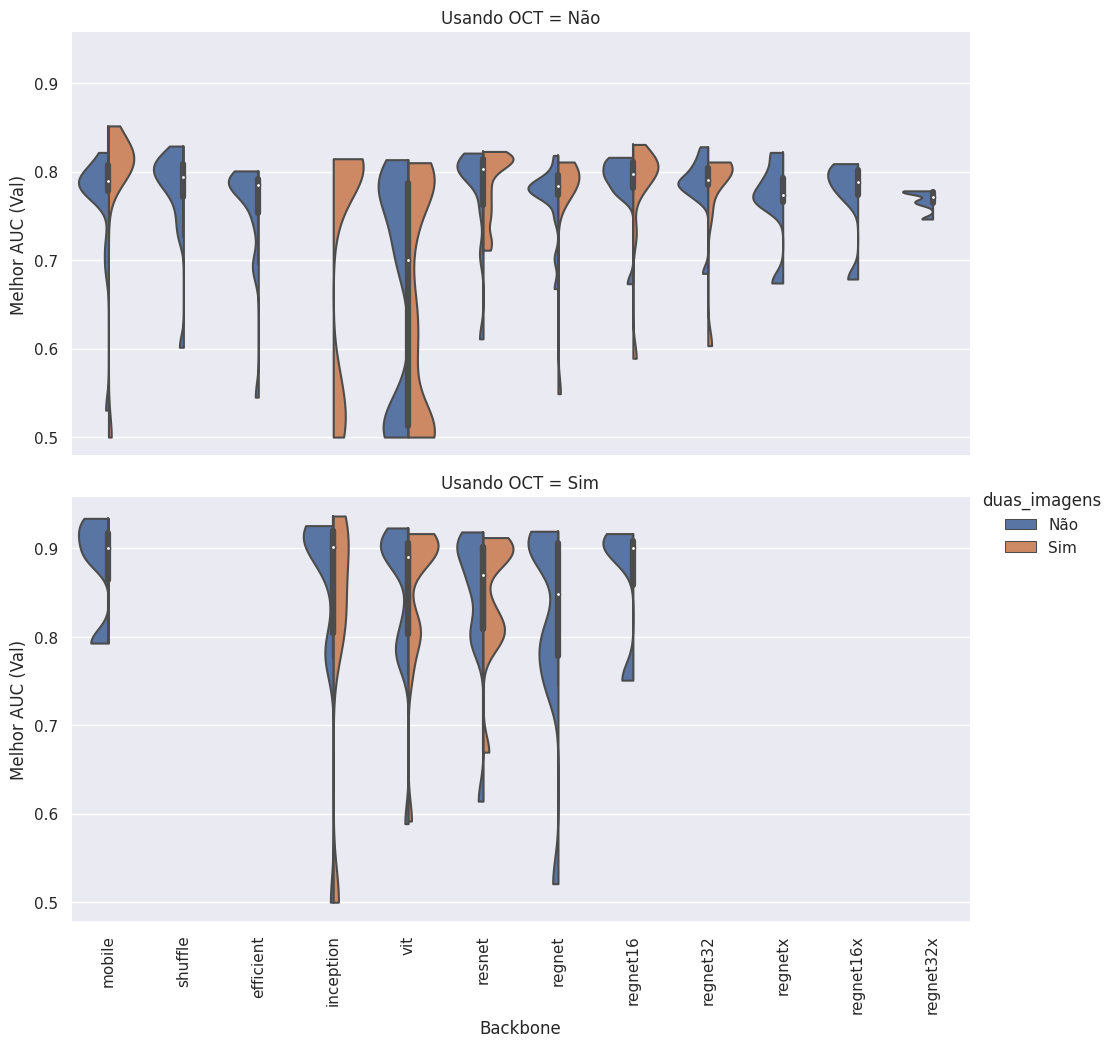

In [16]:

g = sns.catplot(
    data=summary, x="backbone", y="val_best_auc",hue=double_img,row=oct_presence,
    kind="violin", bw=.25, cut=0,split=True, height=5, aspect=2)
g.set_ylabels("Melhor AUC (Val)", fontsize=12) # not set_label
g.set_xlabels("Backbone", fontsize=12) # not set_label
pyplot.xticks(rotation=90)




# Estatística da média e do máximo

## Backbone

In [17]:
summary[['val_best_auc','val_avg_auc','backbone']].groupby("backbone").agg(['min', 'max','mean','std']).round(2)\
        .reset_index(col_level=0)

backbone val_best_auc                   val_avg_auc                  
                       min   max  mean   std         min   max  mean   std
0   efficient         0.55  0.80  0.76  0.06        0.50  0.72  0.67  0.06
1   inception         0.50  0.94  0.78  0.14        0.50  0.86  0.70  0.12
2      mobile         0.50  0.93  0.78  0.08        0.50  0.84  0.69  0.07
3      regnet         0.52  0.92  0.79  0.08        0.50  0.84  0.70  0.07
4    regnet16         0.59  0.92  0.80  0.06        0.52  0.84  0.71  0.06
5   regnet16x         0.68  0.81  0.77  0.05        0.59  0.74  0.69  0.05
6    regnet32         0.60  0.83  0.78  0.05        0.52  0.73  0.70  0.05
7   regnet32x         0.75  0.78  0.77  0.01        0.63  0.72  0.68  0.04
8     regnetx         0.67  0.82  0.77  0.05        0.58  0.72  0.68  0.05
9      resnet         0.61  0.92  0.80  0.07        0.51  0.83  0.70  0.08
10    shuffle         0.60  0.83  0.78  0.05        0.53  0.73  0.68  0.06
11        vit         0.50  0.92  0.72  0.15        0.50  0.85  0.64  0.12

In [18]:
latex = summary[['val_best_auc','val_avg_auc','backbone']].groupby("backbone").agg(['min', 'max','mean','std']).round(2)\
        .reset_index(col_level=0).set_index("backbone").to_latex(column_format="c|c|c|c|c|c|c|c|c|c",
            multicolumn_format="c|",
            bold_rows=True,
            index=True,
            multirow=False,
            label="tab:aucbackbone",
            caption="Valores médios, desvio padrão, mínimo e máximo, incluindo todas as arquiteturas visuais, dos modelos backbones em relação a AUC")

In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.


In [19]:
with open("../thesis/ppgccufmg/exemplo/tables/mean_std_min_max_backbone_auc.tex", 'w') as table:
    table.write(latex)

In [20]:
latex = summary[['val_best_sp','val_avg_sp','backbone']].groupby("backbone").agg(['min', 'max','mean','std']).round(2)\
        .reset_index(col_level=0).set_index("backbone").to_latex(column_format="c|c|c|c|c|c|c|c|c|c",
            multicolumn_format="c|",
            bold_rows=True,
            index=True,
            multirow=False,
            label="tab:spbackbone",
            caption="Valores médios, desvio padrão, mínimo e máximo, incluindo todas as arquiteturas visuais, dos modelos backbones em relação a especificidade")

In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.


In [21]:
with open("../thesis/ppgccufmg/exemplo/tables/mean_std_min_max_backbone_sp.tex", 'w') as table:
    table.write(latex)

In [22]:
latex = summary[['val_best_sn','val_avg_sn','backbone']].groupby("backbone").agg(['min', 'max','mean','std']).round(2)\
        .reset_index(col_level=0).set_index("backbone").to_latex(column_format="c|c|c|c|c|c|c|c|c|c",
            multicolumn_format="c|",
            bold_rows=True,
            index=True,
            multirow=False,
            label="tab:snbackbone",
            caption="Valores médios, desvio padrão, mínimo e máximo, incluindo todas as arquiteturas visuais, dos modelos backbones em relação a sensibilidade")

In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.


In [23]:
with open("../thesis/ppgccufmg/exemplo/tables/mean_std_min_max_backbone_sn.tex", 'w') as table:
    table.write(latex)

## Double Image e OCT

In [24]:
summary[['val_best_auc','val_avg_auc',oct_presence,double_img]].groupby([double_img,oct_presence]).agg(['min', 'max','mean','std']).round(2)\
        .reset_index(col_level=0)

duas_imagens Usando OCT val_best_auc                   val_avg_auc        \
                                   min   max  mean   std         min   max   
0          Não        Não          0.5  0.83  0.76  0.08         0.5  0.74   
1          Não        Sim          0.5  0.93  0.85  0.10         0.5  0.86   
2          Sim        Não          0.5  0.85  0.73  0.11         0.5  0.76   
3          Sim        Sim          0.5  0.94  0.84  0.10         0.5  0.84   

               
   mean   std  
0  0.67  0.07  
1  0.75  0.09  
2  0.66  0.10  
3  0.74  0.09

In [25]:
latex = summary[['val_best_auc','val_avg_auc', oct_presence,double_img]].groupby([double_img,oct_presence]).agg(['min', 'max','mean','std']).round(2)\
        .reset_index(col_level=0).set_index([double_img,oct_presence]).to_latex(column_format="c|c|c|c|c|c|c|c|c|c",
            multicolumn_format="c|",
            bold_rows=True,
            index=True,
            multirow=False,
            label="tab:aucdboct",
            caption="Valores médios, desvio padrão, mínimo e máximo, incluindo todas as arquitetura dos modelos, separado por uso de duas imagens e OCT")

In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.


In [26]:
with open("../thesis/ppgccufmg/exemplo/tables/mean_std_min_max_double_oct_auc.tex", 'w') as table:
    table.write(latex)

## Modelos TOP

In [27]:
summary['rank_max_auc'] = summary["val_best_auc"].rank(ascending=False,method="first").astype(int)
summary['rank_avg_auc'] = summary["val_avg_auc"].rank(ascending=False,method="first").astype(int)

In [28]:
summary.sort_values("rank_max_auc")

,model_id,k_fold,frac_val,val_best_acc,val_best_auc,val_best_sp,val_best_sn,val_avg_acc,val_avg_auc,val_avg_sp,val_avg_sn,train_best_acc,train_best_auc,train_best_sp,train_best_sn,train_avg_acc,train_avg_auc,train_avg_sp,train_avg_sn,host_name,is_inception,optim,lr,epochs,double_img,output_tab,backbone,feature_extract,early_start,timestamp,total_hours,average_cross_hours,torchvision_version,torch_version,Usando OCT,duas_imagens,rank_max_auc,rank_avg_auc
94,e4be89e62af347ebb6889e03f3bb6a4f,NaN,0.2,0.955414,0.936643,1.000000,0.956522,0.870955,0.813581,0.952162,0.675000,0.961730,0.948405,1.000000,0.922156,0.925474,0.890341,0.969424,0.811257,magneto,True,radam,0.0100,100.0,1.0,5.0,inception,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Sim,Sim,1,28
624,8278647f88394f01a7caab2ade3d8295,NaN,0.2,0.942675,0.933999,1.000000,0.913043,0.891783,0.843396,0.960270,0.726522,0.981697,0.976276,0.993088,0.964072,0.940832,0.914089,0.974286,0.853892,magneto,False,adam,0.0010,100.0,0.0,5.0,mobile,False,100.0,2022-11-07 06:56:10.493098,04:24:22.68,04:24:22.68,0.13.0+cu113,1.12.0+cu113,Sim,Não,2,8
93,cfe7535b4f3541adbc365ad1b82411f9,NaN,0.2,0.949045,0.929495,1.000000,0.913043,0.893503,0.842003,0.966396,0.717609,0.970050,0.960843,1.000000,0.940120,0.932879,0.896278,0.978664,0.813892,magneto,True,ranger,0.0100,100.0,1.0,5.0,inception,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Sim,Sim,3,10
77,63d6a93a02c1451fa2d0deb5537c228a,NaN,0.2,0.949045,0.925774,1.000000,0.913043,0.912102,0.863176,0.981351,0.745000,0.960067,0.944721,0.993088,0.910180,0.928403,0.888942,0.977765,0.800120,magneto,True,adam,0.0100,100.0,0.0,5.0,inception,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Sim,Não,4,1
79,a4fe240bc5ed47c49e505b092f9ac61e,NaN,0.2,0.942675,0.924990,1.000000,0.913043,0.842930,0.782304,0.928739,0.635870,0.986689,0.983416,1.000000,0.976048,0.902579,0.851280,0.966751,0.735808,magneto,True,sgd,0.0100,100.0,0.0,5.0,inception,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Sim,Não,5,47
78,0c3ba6344db246a4b808bc1f0b19c624,NaN,0.2,0.949045,0.923130,1.000000,0.956522,0.899299,0.845720,0.975135,0.716304,0.971714,0.950944,1.000000,0.910180,0.930250,0.888877,0.982005,0.795749,magneto,True,ranger,0.0100,100.0,0.0,5.0,inception,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Sim,Não,6,4
197,04ff79a9ee5d4750812696e16fe0e713,NaN,0.2,0.942675,0.923130,1.000000,0.913043,0.895605,0.842662,0.970541,0.714783,0.966722,0.947488,1.000000,0.916168,0.925308,0.886744,0.973548,0.799940,loki,False,radam,0.0100,100.0,0.0,5.0,vit,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Sim,Não,7,9
76,9f0029183aca436fb265dad66303f671,NaN,0.2,0.942675,0.921269,1.000000,0.956522,0.897643,0.844549,0.972793,0.716304,0.963394,0.948867,1.000000,0.922156,0.930083,0.892519,0.977074,0.807964,magneto,True,radam,0.0100,100.0,0.0,5.0,inception,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Sim,Não,8,5
180,38a1722691744c27823fc408d7fd253b,NaN,0.2,0.949045,0.919409,1.000000,0.847826,0.852484,0.794089,0.935135,0.653043,0.958403,0.934359,1.000000,0.880240,0.903311,0.851474,0.968157,0.734790,magneto,True,ranger,0.0005,100.0,0.0,5.0,inception,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Sim,Não,9,40
185,4d9886e7326a445cba8ee17c0fab421c,NaN,0.2,0.949045,0.919409,1.000000,0.869565,0.867707,0.810902,0.948108,0.673696,0.965058,0.946335,0.990783,0.904192,0.915291,0.871502,0.970069,0.772934,magneto,True,radam,0.0010,100.0,1.0,5.0,inception,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Sim,Sim,10,30


In [29]:
summary['rank_max_auc_oct_double'] = summary.groupby([double_img,oct_presence])["val_best_auc"].rank(ascending=False,method="first").astype(int)
summary['rank_avg_auc_oct_double'] = summary.groupby([double_img,oct_presence])["val_avg_auc"].rank(ascending=False,method="first").astype(int)

In [30]:
summary["rank_avg"] = summary[["rank_max_auc_oct_double","rank_avg_auc_oct_double","rank_max_auc","rank_avg_auc"]].mean(axis=1)

In [31]:
summary.groupby("backbone")["rank_avg"].mean().astype(int).to_frame().reset_index().set_index("backbone")

,rank_avg
backbone,
efficient,190
inception,109
mobile,152
regnet,146
regnet16,125
regnet16x,160
regnet32,141
regnet32x,204
regnetx,183


In [32]:
latex = summary.groupby("backbone")["rank_avg"].mean().astype(int).to_frame().reset_index().to_latex(column_format="|>{\\bfseries}c|c|",
            bold_rows=True,
            index=False,
            escape=True,   
            label="tab:rankingbackbone",
            caption="Rank médio dos backbones considerando todas as arquiteturas visuais.")

In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.


In [33]:
with open("../thesis/ppgccufmg/exemplo/tables/ranking_backbone.tex", 'w') as table:
    table.write(latex)

# Explicabilidade 

In [27]:
total_train_samples = 100
total_test_samples = 50

In [15]:
summary[(summary[double_img] == "Não") & (summary[oct_presence] == "Sim")].sort_values("val_best_auc")

,model_id,k_fold,frac_val,val_best_acc,val_best_auc,val_best_sp,val_best_sn,val_avg_acc,val_avg_auc,val_avg_sp,val_avg_sn,train_best_acc,train_best_auc,train_best_sp,train_best_sn,train_avg_acc,train_avg_auc,train_avg_sp,train_avg_sn,host_name,is_inception,optim,lr,epochs,double_img,output_tab,backbone,feature_extract,early_start,timestamp,total_hours,average_cross_hours,torchvision_version,torch_version,Usando OCT,duas_imagens
178,cc06ea0b6061485fb0a159745fa3a3f9,NaN,0.2,0.707006,0.500000,1.0,0.000000,0.707006,0.500000,1.000000,0.000000,0.722130,0.500000,1.000000,0.011976,0.722063,0.499991,0.999862,0.000120,magneto,True,sgd,0.0001,100.0,0.0,5.0,inception,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Sim,Não
595,d11fa69e113444ecb473cca2ee3bc5a0,NaN,0.2,0.707006,0.520956,1.0,0.086957,0.706943,0.500210,0.999550,0.000870,0.722130,0.566958,1.000000,0.401198,0.721248,0.500660,0.997189,0.004132,magneto,False,sgd,0.0001,100.0,0.0,5.0,regnet,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Sim,Não
120,2f0a7656d24f4bad82d7c6f29e802c81,NaN,0.2,0.751592,0.588817,1.0,0.195652,0.707834,0.502431,0.998559,0.006304,0.727121,0.538453,1.000000,0.113772,0.721997,0.502192,0.996959,0.007425,loki,False,sgd,0.0100,100.0,0.0,5.0,vit,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Sim,Não
266,2fc085e32c5841bf8971e700df3a4256,NaN,0.2,0.751592,0.614277,1.0,0.282609,0.711210,0.510993,0.994595,0.027391,0.785358,0.635876,1.000000,0.299401,0.729468,0.516188,0.996267,0.036108,loki,False,sgd,0.0001,100.0,0.0,5.0,resnet,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Sim,Não
593,40489489892f47e4af838ab458c2337b,NaN,0.2,0.815287,0.743929,1.0,0.673913,0.754331,0.668153,0.876306,0.460000,0.965058,0.955545,1.000000,0.934132,0.892729,0.837368,0.961982,0.712754,magneto,False,ranger,0.0001,100.0,0.0,5.0,regnet,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Sim,Não
603,2fa497c67b724be380264a52923decb2,NaN,0.2,0.828025,0.751077,1.0,0.695652,0.760510,0.663102,0.898378,0.427826,0.951747,0.931593,1.000000,0.898204,0.859235,0.781225,0.956820,0.605629,magneto,False,sgd,0.0010,100.0,0.0,5.0,regnet16,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Sim,Não
597,196f0f403e604f0ba9351cbd1bd409c6,NaN,0.2,0.821656,0.752938,1.0,0.652174,0.744331,0.612070,0.931532,0.292609,0.913478,0.884834,1.000000,0.820359,0.804193,0.682293,0.956682,0.407904,magneto,False,sgd,0.0005,100.0,0.0,5.0,regnet,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Sim,Não
199,874f57c1ac9041f0ba7109b1867c8ce5,NaN,0.2,0.821656,0.771250,1.0,0.826087,0.769809,0.688901,0.884324,0.493478,0.923461,0.888063,0.983871,0.808383,0.875075,0.815088,0.950115,0.680060,loki,False,radam,0.0001,100.0,0.0,5.0,vit,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Sim,Não
183,5185e272beb54da2bce49640cfa13c91,NaN,0.2,0.808917,0.775754,1.0,0.695652,0.746051,0.619842,0.924685,0.315000,0.923461,0.903488,1.000000,0.862275,0.820233,0.705832,0.963341,0.448323,magneto,True,sgd,0.0005,100.0,0.0,5.0,inception,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Sim,Não
121,ae2d1dc9c0ee4248929f96907491577e,NaN,0.2,0.828025,0.778398,1.0,0.826087,0.785287,0.706849,0.896306,0.517391,0.968386,0.950482,1.000000,0.910180,0.901015,0.853033,0.961037,0.745030,loki,False,sgd,0.0010,100.0,0.0,5.0,vit,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Sim,Não


## One image 

In [17]:
model_id = "485501a078a64dcca52829771085aa9b"
row = summary[summary["model_id"] == model_id]

In [18]:
row

,model_id,k_fold,frac_val,val_best_acc,val_best_auc,val_best_sp,val_best_sn,val_avg_acc,val_avg_auc,val_avg_sp,val_avg_sn,train_best_acc,train_best_auc,train_best_sp,train_best_sn,train_avg_acc,train_avg_auc,train_avg_sp,train_avg_sn,host_name,is_inception,optim,lr,epochs,double_img,output_tab,backbone,feature_extract,early_start,Usando OCT,duas_imagens
559,485501a078a64dcca52829771085aa9b,NaN,0.2,0.859873,0.821876,0.990991,0.782609,0.790446,0.721509,0.888018,0.555,0.946755,0.931821,0.974654,0.898204,0.886955,0.837331,0.949032,0.725629,solid,False,adam,0.0005,100.0,0.0,0.0,regnetx,False,100.0,Não,Não


In [19]:
model_name = row["backbone"].values[0]
pretrained = False
feature_extract = False
double_img_bool = True if row["double_img"].values[0] > 0 else False
output_tab = row["output_tab"].values[0] if row["output_tab"].values[0] > 0 else None 

In [47]:
model, _ = init_model(model_name,pretrained, feature_extract, double_img_bool, output_tab, ft_size)

Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.


In [48]:
model.load_state_dict(torch.load("../models/" + str(model_id) + "/" + str(model_id) + ".pth"))

<All keys matched successfully>

In [20]:
train_loader = torch.load("../models/" + str(model_id) + "/train_dataloader_" + str(model_id) + ".pth")
val_loader = torch.load("../models/" + str(model_id) + "/val_dataloader_" + str(model_id) + ".pth")

In [68]:
batch_val = next(iter(val_loader))
batch_train = next(iter(train_loader))

In [69]:
photos1_train, photos2_train, ft_numerical_train , labels_train = batch_train
photos1_val, photos2_val, ft_numerical_val , labels_val = batch_val

In [81]:
torchsummary(model, input_data=photos1)

Layer (type:depth-idx)                                  Output Shape              Param #
RegNet                                                  [16, 1]                   --
├─SimpleStemIN: 1-1                                     [16, 32, 112, 112]        --
│    └─Conv2d: 2-1                                      [16, 32, 112, 112]        864
│    └─BatchNorm2d: 2-2                                 [16, 32, 112, 112]        64
│    └─ReLU: 2-3                                        [16, 32, 112, 112]        25,690,112
├─Sequential: 1-2                                       [16, 672, 7, 7]           --
│    └─AnyStage: 2-4                                    [16, 64, 56, 56]          --
│    │    └─ResBottleneckBlock: 3-1                     [16, 64, 56, 56]          77,088,256
│    └─AnyStage: 2-5                                    [16, 128, 28, 28]         --
│    │    └─ResBottleneckBlock: 3-2                     [16, 128, 28, 28]         38,587,392
│    │    └─ResBottleneckBlock: 3-3

In [70]:
e = shap.DeepExplainer(model, photos1_train)

In [71]:
shap_values = e.shap_values(photos1_val)

Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.


In [153]:
shap_numpy = [np.swapaxes(np.swapaxes(s, 1, -1), 1, 2) for s in shap_values]
test_numpy = np.swapaxes(np.swapaxes(photos1_val.numpy(), 1, -1), 1, 2)

In [188]:
def imshow(image):
    npimg = image.numpy()
    npimg = np.transpose(npimg, (1,2,0))
    npimg = ((npimg * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406])
    return npimg

In [189]:
only_image =  imshow(photos1_val[10].reshape(3,224,224))

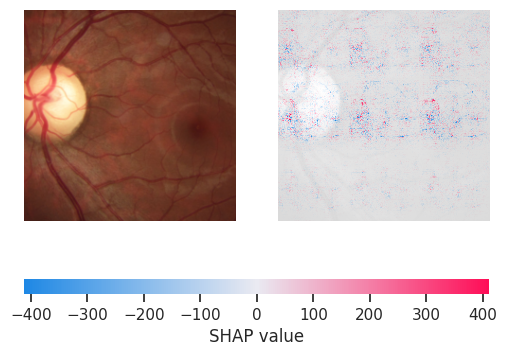

In [191]:
shap.image_plot(shap_values.reshape(16,224,224,3)[10],  only_image.reshape(224,224,3),width=20,aspect=0.2)

## Two images

In [16]:
model_id = "79397cdfe56945389fad0dbd32d3fe7a"
row = summary[summary["model_id"] == model_id]

In [17]:
row

,model_id,k_fold,frac_val,val_best_acc,val_best_auc,val_best_sp,val_best_sn,val_avg_acc,val_avg_auc,val_avg_sp,val_avg_sn,train_best_acc,train_best_auc,train_best_sp,train_best_sn,train_avg_acc,train_avg_auc,train_avg_sp,train_avg_sn,host_name,is_inception,optim,lr,epochs,double_img,output_tab,backbone,feature_extract,early_start,timestamp,total_hours,average_cross_hours,torchvision_version,torch_version,Usando OCT,duas_imagens
622,79397cdfe56945389fad0dbd32d3fe7a,NaN,0.2,0.923567,0.88866,1.0,0.913043,0.848726,0.784494,0.93964,0.629348,0.988353,0.984568,0.997696,0.976048,0.935907,0.905706,0.973687,0.837725,magneto,False,ranger,0.001,100.0,0.0,5.0,mobile,False,100.0,2022-11-07 06:55:51.164415,04:24:03.35,04:24:03.35,0.13.0+cu113,1.12.0+cu113,Sim,Não


In [18]:
model_name = row["backbone"].values[0]
pretrained = False
feature_extract = False
double_img_bool = True if row["double_img"].values[0] > 0 else False
output_tab = row["output_tab"].values[0] if row["output_tab"].values[0] > 0 else None 

In [22]:
False

False

In [24]:
model, _ = init_model(model_name,pretrained, feature_extract, double_img_bool, output_tab, ft_size)

Using 'weights' as positional parameter(s) is deprecated since 0.13 and will be removed in 0.15. Please use keyword parameter(s) instead.
Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=None`.


TypeError: empty() received an invalid combination of arguments - got (tuple, dtype=NoneType, device=NoneType), but expected one of:
 * (tuple of ints size, *, tuple of names names, torch.memory_format memory_format, torch.dtype dtype, torch.layout layout, torch.device device, bool pin_memory, bool requires_grad)
 * (tuple of ints size, *, torch.memory_format memory_format, Tensor out, torch.dtype dtype, torch.layout layout, torch.device device, bool pin_memory, bool requires_grad)


In [30]:
model.load_state_dict(torch.load("../models/" + str(model_id) + "/" + str(model_id) + ".pth"))

<All keys matched successfully>

In [21]:
train_loader = torch.load("../models/" + str(model_id) + "/train_dataloader_" + str(model_id) + ".pth")
val_loader = torch.load("../models/" + str(model_id) + "/val_dataloader_" + str(model_id) + ".pth")

In [31]:
batch_val = next(iter(val_loader))
batch_train = next(iter(train_loader))

In [32]:
photos1_train, photos2_train, ft_numerical_train , labels_train = batch_train
photos1_val, photos2_val, ft_numerical_val , labels_val = batch_val

In [33]:
torchsummary(model, input_data=[photos1_train,photos2_train, ft_numerical_train])

Layer (type:depth-idx)                        Output Shape              Param #
MultiInputModel                               [16, 1]                   --
├─Sequential: 1-1                             [16, 2048, 1, 1]          --
│    └─Conv2d: 2-1                            [16, 64, 112, 112]        9,408
│    └─BatchNorm2d: 2-2                       [16, 64, 112, 112]        128
│    └─ReLU: 2-3                              [16, 64, 112, 112]        --
│    └─MaxPool2d: 2-4                         [16, 64, 56, 56]          --
│    └─Sequential: 2-5                        [16, 256, 56, 56]         --
│    │    └─Bottleneck: 3-1                   [16, 256, 56, 56]         75,008
│    │    └─Bottleneck: 3-2                   [16, 256, 56, 56]         70,400
│    │    └─Bottleneck: 3-3                   [16, 256, 56, 56]         70,400
│    └─Sequential: 2-6                        [16, 512, 28, 28]         --
│    │    └─Bottleneck: 3-4                   [16, 512, 28, 28]         379,392

In [34]:
e = shap.GradientExplainer(model, [photos1_train.to("cuda"),photos2_train.to("cuda"), ft_numerical_train.to("cuda")])

In [35]:
shap_values = e.shap_values([photos1_val.to("cuda"),photos2_val.to("cuda"), ft_numerical_val.to("cuda")])

OutOfMemoryError: CUDA out of memory. Tried to allocate 154.00 MiB (GPU 0; 7.93 GiB total capacity; 6.31 GiB already allocated; 149.31 MiB free; 6.59 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

## One image and OCT

In [14]:
model_id = "63d6a93a02c1451fa2d0deb5537c228a"
row = summary[summary["model_id"] == model_id]

In [15]:
row

,model_id,k_fold,frac_val,val_best_acc,val_best_auc,val_best_sp,val_best_sn,val_avg_acc,val_avg_auc,val_avg_sp,val_avg_sn,train_best_acc,train_best_auc,train_best_sp,train_best_sn,train_avg_acc,train_avg_auc,train_avg_sp,train_avg_sn,host_name,is_inception,optim,lr,epochs,double_img,output_tab,backbone,feature_extract,early_start,timestamp,total_hours,average_cross_hours,torchvision_version,torch_version,Usando OCT,duas_imagens
77,63d6a93a02c1451fa2d0deb5537c228a,NaN,0.2,0.949045,0.925774,1.0,0.913043,0.912102,0.863176,0.981351,0.745,0.960067,0.944721,0.993088,0.91018,0.928403,0.888942,0.977765,0.80012,magneto,True,adam,0.01,100.0,0.0,5.0,inception,False,100.0,NaN,NaN,NaN,0.13.0+cu113,1.12.0+cu113,Sim,Não


In [16]:
model_name = row["backbone"].values[0]
pretrained = False
feature_extract = False
double_img_bool = True if row["double_img"].values[0] > 0 else False
output_tab = int(row["output_tab"].values[0]) if row["output_tab"].values[0] > 0 else None 

In [17]:
output_tab

5

In [18]:
model, _ = init_model(model_name,pretrained, feature_extract, double_img_bool, output_tab, ft_size)

Using 'weights' as positional parameter(s) is deprecated since 0.13 and will be removed in 0.15. Please use keyword parameter(s) instead.
Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=None`.
The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.


In [19]:
model.load_state_dict(torch.load("../models/" + str(model_id) + "/" + str(model_id) + ".pth"))

<All keys matched successfully>

In [20]:
train_loader = torch.load("../models/" + str(model_id) + "/train_dataloader_" + str(model_id) + ".pth")
val_loader = torch.load("../models/" + str(model_id) + "/val_dataloader_" + str(model_id) + ".pth")

In [21]:
val_loader.dataset.root_dir = ROOT_DIR
train_loader.dataset.root_dir = ROOT_DIR

In [74]:
photos1_train, photos2_train, ft_numerical_train, photos1_val, photos2_val, ft_numerical_val =\
    get_samples_from_dataloader(train_loader,val_loader,total_train_samples,total_test_samples)

In [79]:
xplainer_multi_pos = shap.DeepExplainer(model, [photos1_train.to("cuda"),photos2_train.to("cuda"),ft_numerical_train.to("cuda")])

RuntimeError: CUDA out of memory. Tried to allocate 272.00 MiB (GPU 0; 7.93 GiB total capacity; 5.74 GiB already allocated; 301.25 MiB free; 6.15 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

In [78]:
shap_values_photo1, shap_values_photo2, shap_values_numerical = xplainer_multi_pos.shap_values([torch.from_numpy(np.stack(photos1_val[:total_test_samples])).to("cuda"),
                                                    torch.from_numpy(np.stack(photos2_val[:total_test_samples])).to("cuda"),
                                                    torch.from_numpy(np.stack(ft_numerical_val[:total_test_samples])).to("cuda")])

Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.


RuntimeError: CUDA out of memory. Tried to allocate 262.00 MiB (GPU 0; 7.93 GiB total capacity; 5.54 GiB already allocated; 298.19 MiB free; 6.15 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

In [44]:
photos1_val.shape

torch.Size([16, 3, 299, 299])

In [46]:
only_image_1 =  imshow(photos1_val[10].reshape(3,299,299))
only_image_2 =  imshow(photos2_val[10].reshape(3,299,299))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


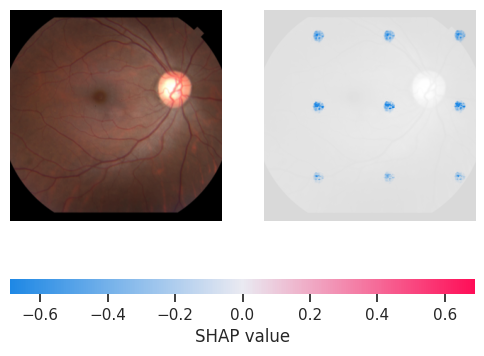

In [48]:
shap.image_plot(shap_values_photo1.reshape(16,299,299,3)[10],  only_image_1.reshape(299,299,3),width=20,aspect=0.2)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


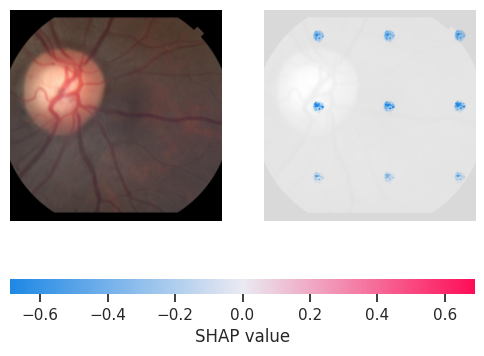

In [51]:
shap.image_plot(shap_values_photo1.reshape(16,299,299,3)[10],  only_image_2.reshape(299,299,3),width=20,aspect=0.2)

In [63]:
labels_train

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1])

In [61]:
shap_values_numerical.shape

(16, 24)

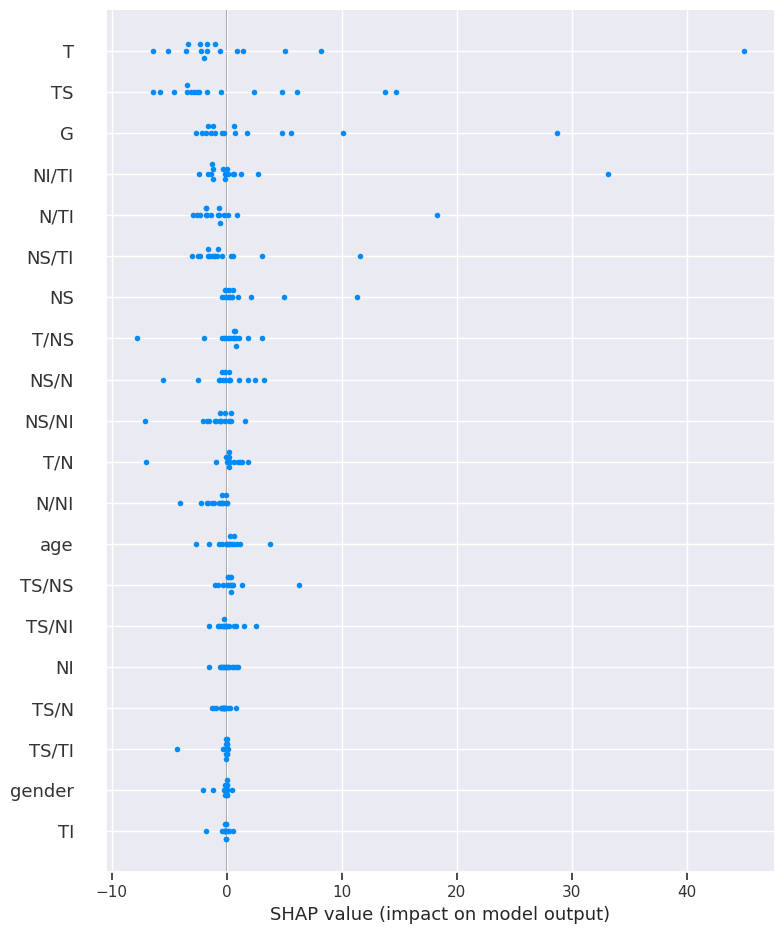

In [62]:
shap.summary_plot(shap_values_numerical, features_name)

# Benefícios 

- Regnet é flexível, e é possível escolher arquiteturas que contém masi parametros de treinamento para melhor acurácia 
- Pode ser usada em grande escala
- Pode ser utilizada em dispositivos pequenos como Mobile 
- Pode ser treinado com um número menor de imagens, sem a necessidade de coletar um número grande. 
- É eficiente, considerando a tabela abaixo
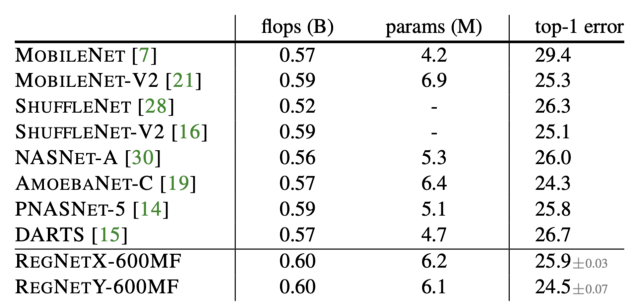
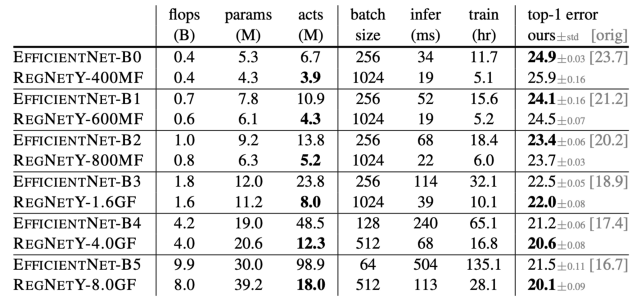